In [1]:
import os
# Get the current working directory
current_dir = os.getcwd()
# Set the data directory to the parent directory of the current working directory
wdir = os.path.dirname(current_dir)
# Change the current working directory to the parent directory
os.chdir(wdir)

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib import rcParams


In [2]:
# Set the font globally
rcParams['font.family'] = 'Arial'
rcParams['font.size'] = 9
rcParams['axes.titlesize'] = 9
rcParams['axes.labelsize'] = 9
rcParams['xtick.labelsize'] = 9
rcParams['ytick.labelsize'] = 9
rcParams['legend.fontsize'] = 9

In [6]:
# --------------------
# Load data
# --------------------
#============================================================
# LEFT PANEL — Data
# ============================================================
data = np.loadtxt(
    "data/Supplementary_Fig_8/heatmap_mu_0.01_more_data_v2.txt"
)
y = np.loadtxt(
    "data/Supplementary_Fig_8/new_list_cd.txt"
)[0:8]
t_ = np.loadtxt(
    "data/Supplementary_Fig_8/times_heatmap_1.txt"
)
# ============================================================
# RIGHT PANEL — Histogram
# ============================================================
all_slopes = np.loadtxt(
    "data/Supplementary_Fig_8/all_slopes_suplementary_fig_M10000_mu2.txt"
)


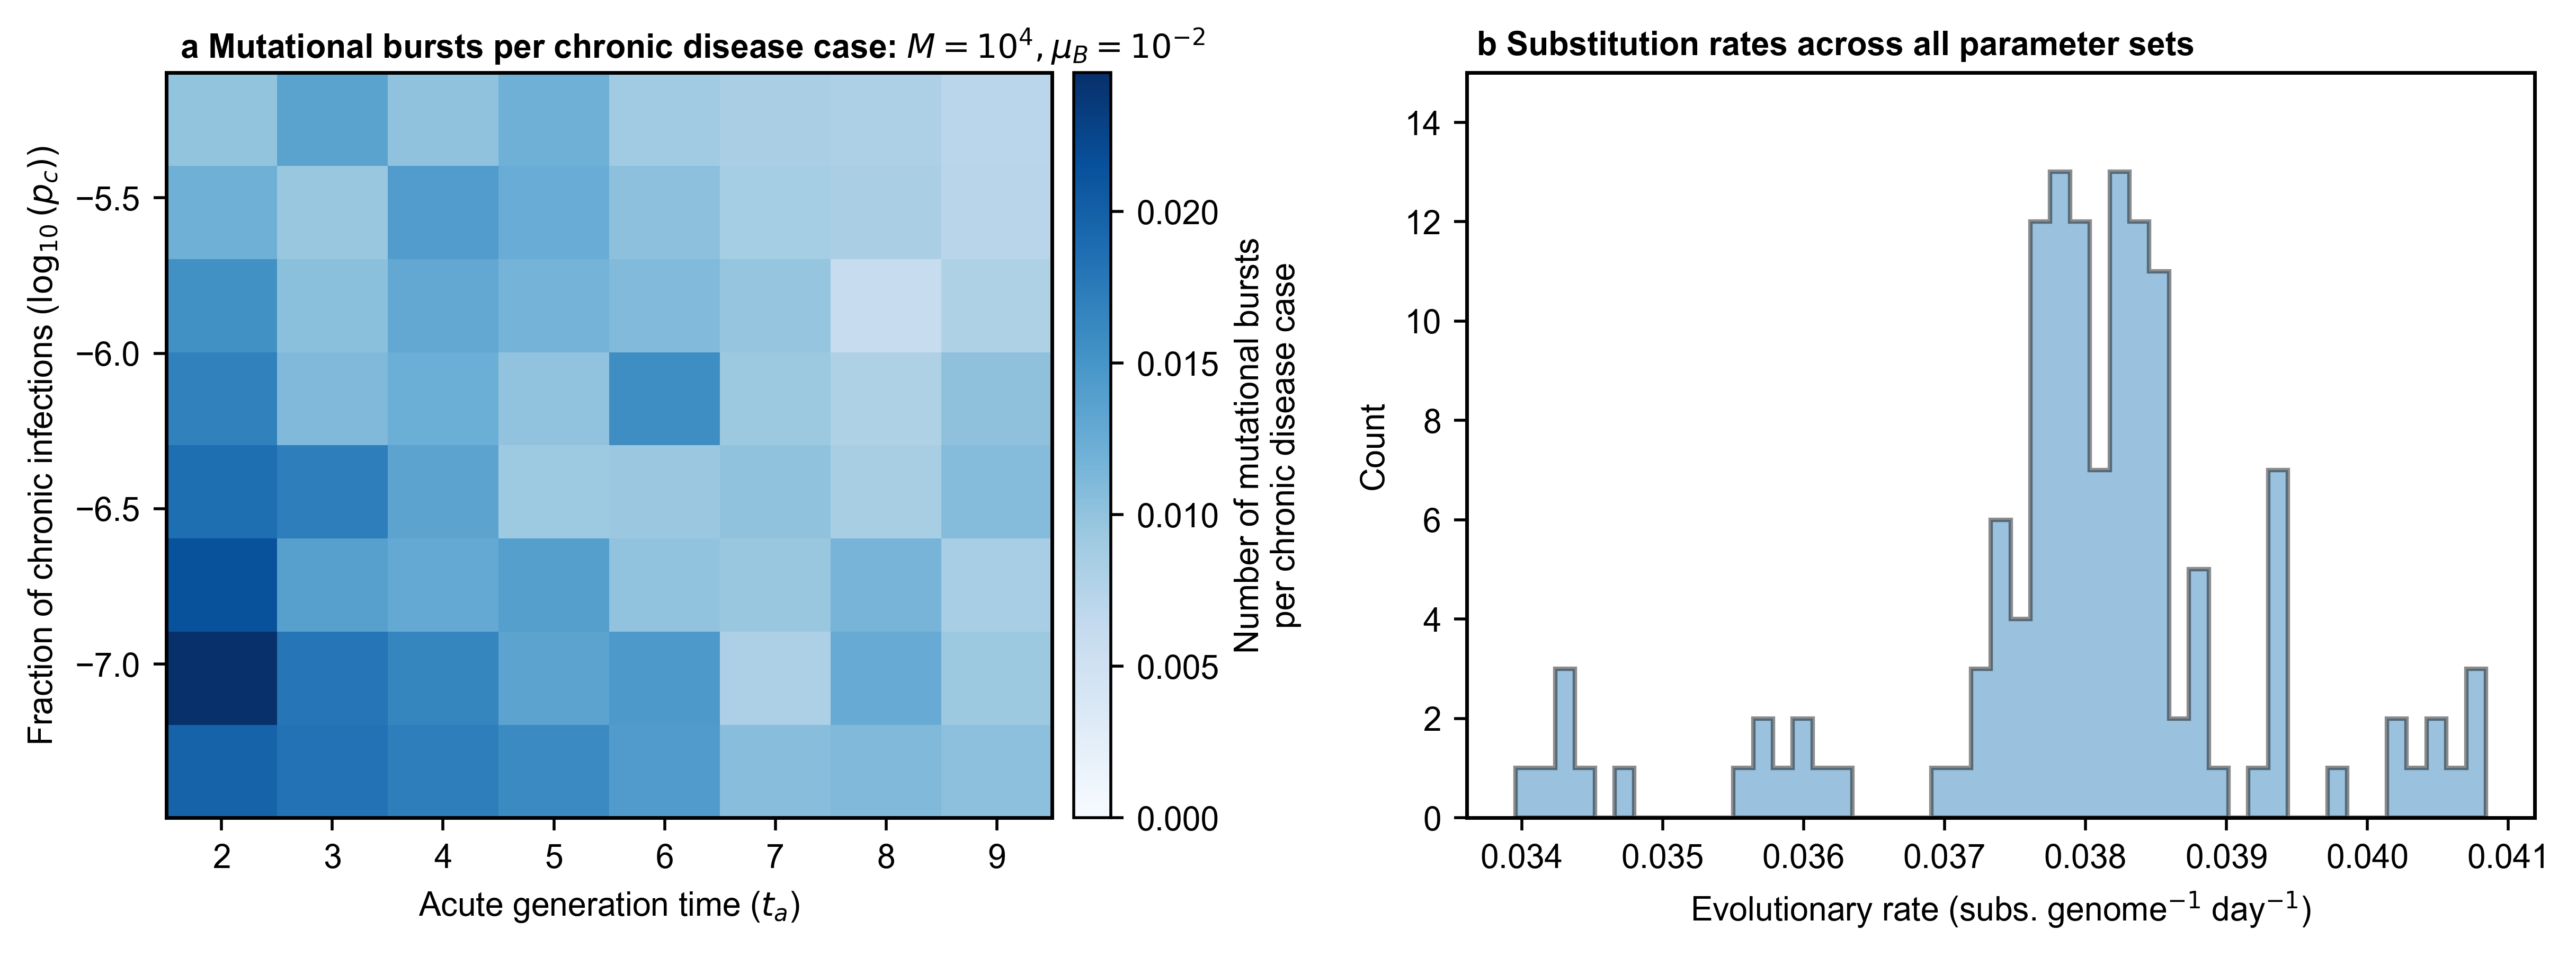

In [5]:
def cm2inch(x): return float(x)/2.54

plotwidth    = cm2inch(8.90)
# ============================================================
# Figure layout — 1 row, 2 columns
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(2.8*plotwidth, plotwidth),dpi=500)

ax_hm, ax_hist = axes


im = ax_hm.imshow(
    data,
    aspect="auto",
    cmap="Blues",
    origin="lower",
    extent=[t_.min()-0.5, t_.max()+0.5,
            np.log10(y).min(), np.log10(y).max()],
    vmin=0.0,
    vmax=data.max()
)

cbar = fig.colorbar(im, ax=ax_hm, pad=0.02)
cbar.set_label(
    "Number of mutational bursts\nper chronic disease case"
)

ax_hm.set_xlabel(r"Acute generation time ($t_a$)")
ax_hm.set_ylabel(r"Fraction of chronic infections ($\log_{10}(p_c)$)")

fig.text(0.27, 0.99, 'a Mutational bursts per chronic disease case: $M=10^{4}, \mu_B=10^{-2}$', ha='center', va='center',weight='bold')
fig.text(0.71, 0.99, 'b Substitution rates across all parameter sets', ha='center', va='center',weight='bold')


bins = np.linspace(all_slopes.min(), all_slopes.max(), 50)

ax_hist.hist(
    all_slopes,
    bins=bins,
    histtype="stepfilled",
    alpha=0.45,
    linewidth=1.2,
    edgecolor="black"
)

ax_hist.set_xlabel(
    r"Evolutionary rate (subs. genome$^{-1}$ day$^{-1}$)"
)
ax_hist.set_ylabel("Count")
ax_hist.set_ylim(0, 15)

for ax in axes:
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.0)

plt.tight_layout()
plt.show()
